# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Vincent Valentino | 5054251016 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [30]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
bank = pd.read_csv("bankruptcy.csv")
bank.columns = bank.columns.str.strip()
bank.shape

(6819, 96)

In [3]:
bank.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [4]:
bank.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [29]:
extreme = [c for c in bank.columns if bank[c].max() > 1e8]
print(f"Jumlah fitur dengan nilai ekstrem (> 10^8): {len(extreme)}")
display(bank[extreme].agg(["min", "median", "max"]).T)

Jumlah fitur dengan nilai ekstrem (> 10^8): 24


,min,median,max
Operating Expense Rate,0.0,2.777589e-04,9.990000e+09
Research and development expense rate,0.0,5.090000e+08,9.980000e+09
Interest-bearing debt interest rate,0.0,3.210321e-04,9.900000e+08
Revenue Per Share (Yuan ¥),0.0,2.737571e-02,3.020000e+09
Total Asset Growth Rate,0.0,6.400000e+09,9.990000e+09
Net Value Growth Rate,0.0,4.619555e-04,9.330000e+09
Current Ratio,0.0,1.058717e-02,2.750000e+09
Quick Ratio,0.0,7.412472e-03,9.230000e+09
Total debt/Total net worth,0.0,5.546284e-03,9.940000e+09
Accounts Receivable Turnover,0.0,9.678107e-04,9.740000e+09


Terdapat 24 fitur dengan nilai mencapai 9.99 × 10⁹. Pada database keuangan TEJ (Taiwan Economic Journal), nilai ini
biasanya merupakan indikator capping atau hasil pembagian dengan angka mendekati nol (misalnya beban bunga tanpa pinjaman). Namun, tidak perlu dihandle soalnya Decision Tree kebal terhadap outlier.

In [5]:
bank.dtypes

Bankrupt?                                                    int64
ROA(C) before interest and depreciation before interest    float64
ROA(A) before interest and % after tax                     float64
ROA(B) before interest and depreciation after tax          float64
Operating Gross Margin                                     float64
                                                            ...   
Liability to Equity                                        float64
Degree of Financial Leverage (DFL)                         float64
Interest Coverage Ratio (Interest expense to EBIT)         float64
Net Income Flag                                              int64
Equity to Liability                                        float64
Length: 96, dtype: object

In [6]:
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net Interest Rate            

In [7]:
display(bank.duplicated().sum())
display(bank.isnull().sum())

np.int64(0)

Bankrupt?                                                  0
ROA(C) before interest and depreciation before interest    0
ROA(A) before interest and % after tax                     0
ROA(B) before interest and depreciation after tax          0
Operating Gross Margin                                     0
                                                          ..
Liability to Equity                                        0
Degree of Financial Leverage (DFL)                         0
Interest Coverage Ratio (Interest expense to EBIT)         0
Net Income Flag                                            0
Equity to Liability                                        0
Length: 96, dtype: int64

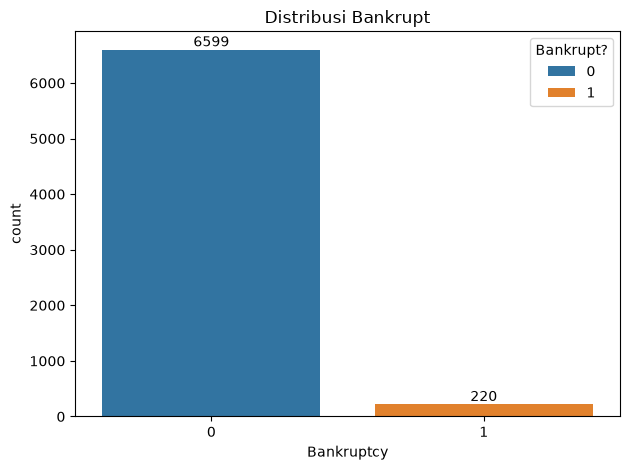

In [8]:
values = bank["Bankrupt?"].value_counts().reset_index()
ax = sb.barplot(data=values, x="Bankrupt?", y="count", hue="Bankrupt?")
ax.set_title("Distribusi Bankrupt")
ax.set_xlabel("Bankruptcy")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

Distribusi sangat right-skewed, menandakan harus di stratify ketika training.

Karena fitur yang terlalu banyak (96 kolom), sehingga akan ambil 15 fitur ter-relevan

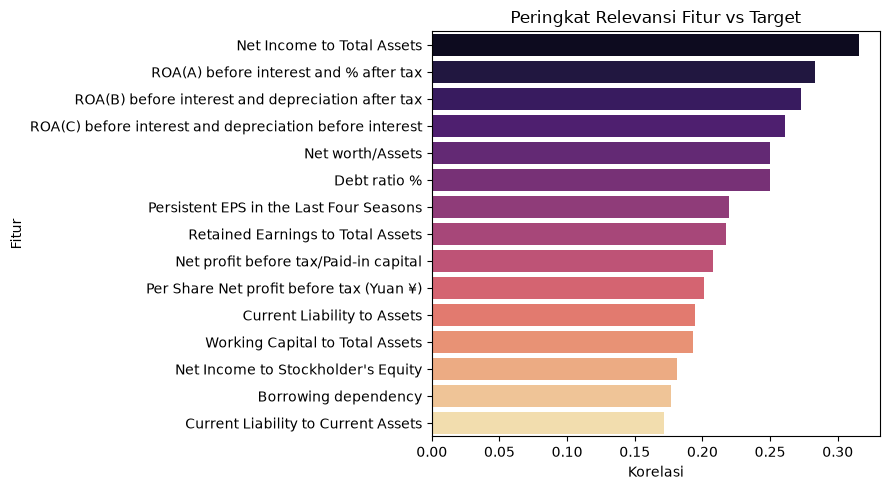

In [9]:
corr = bank.corr()["Bankrupt?"].drop("Bankrupt?").abs().sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 5))
sb.barplot(x=corr.values, y=corr.index, hue=corr.index, palette="magma", legend=False)
plt.title("Peringkat Relevansi Fitur vs Target")
plt.xlabel("Korelasi")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

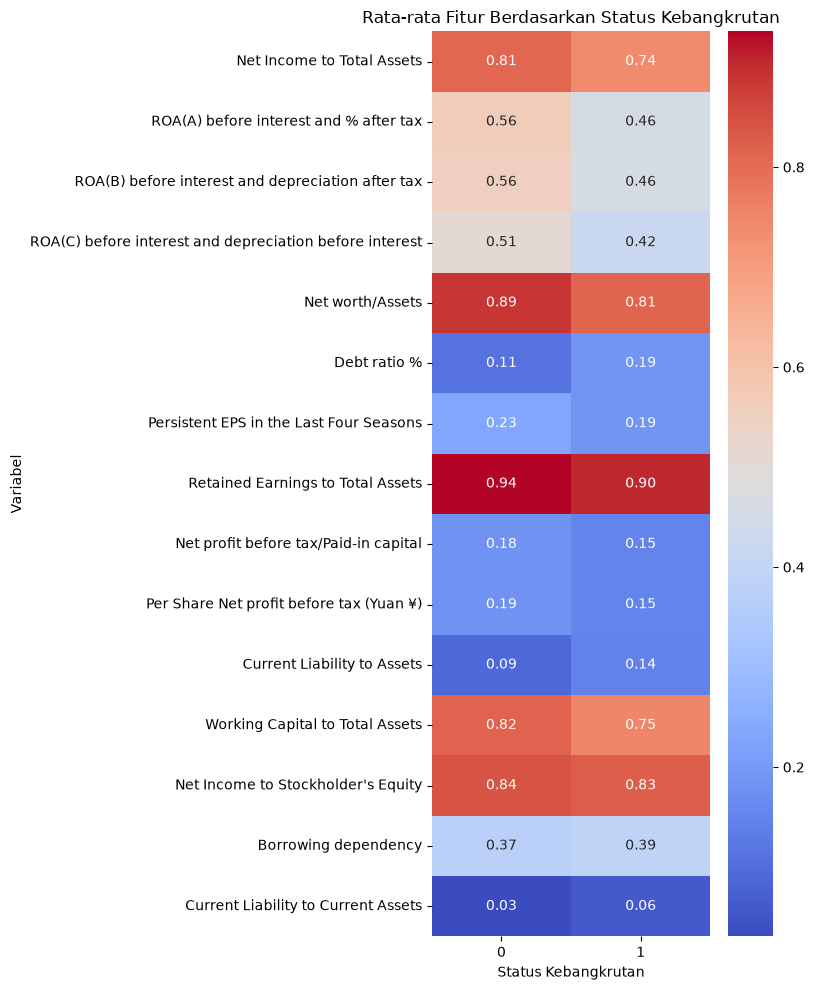

In [10]:
top = corr.index.tolist()

mean = bank.groupby("Bankrupt?")[top].mean().T
plt.figure(figsize=(8, 10))
sb.heatmap(mean, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Rata-rata Fitur Berdasarkan Status Kebangkrutan")
plt.xlabel("Status Kebangkrutan")
plt.ylabel("Variabel")

plt.tight_layout()
plt.show()

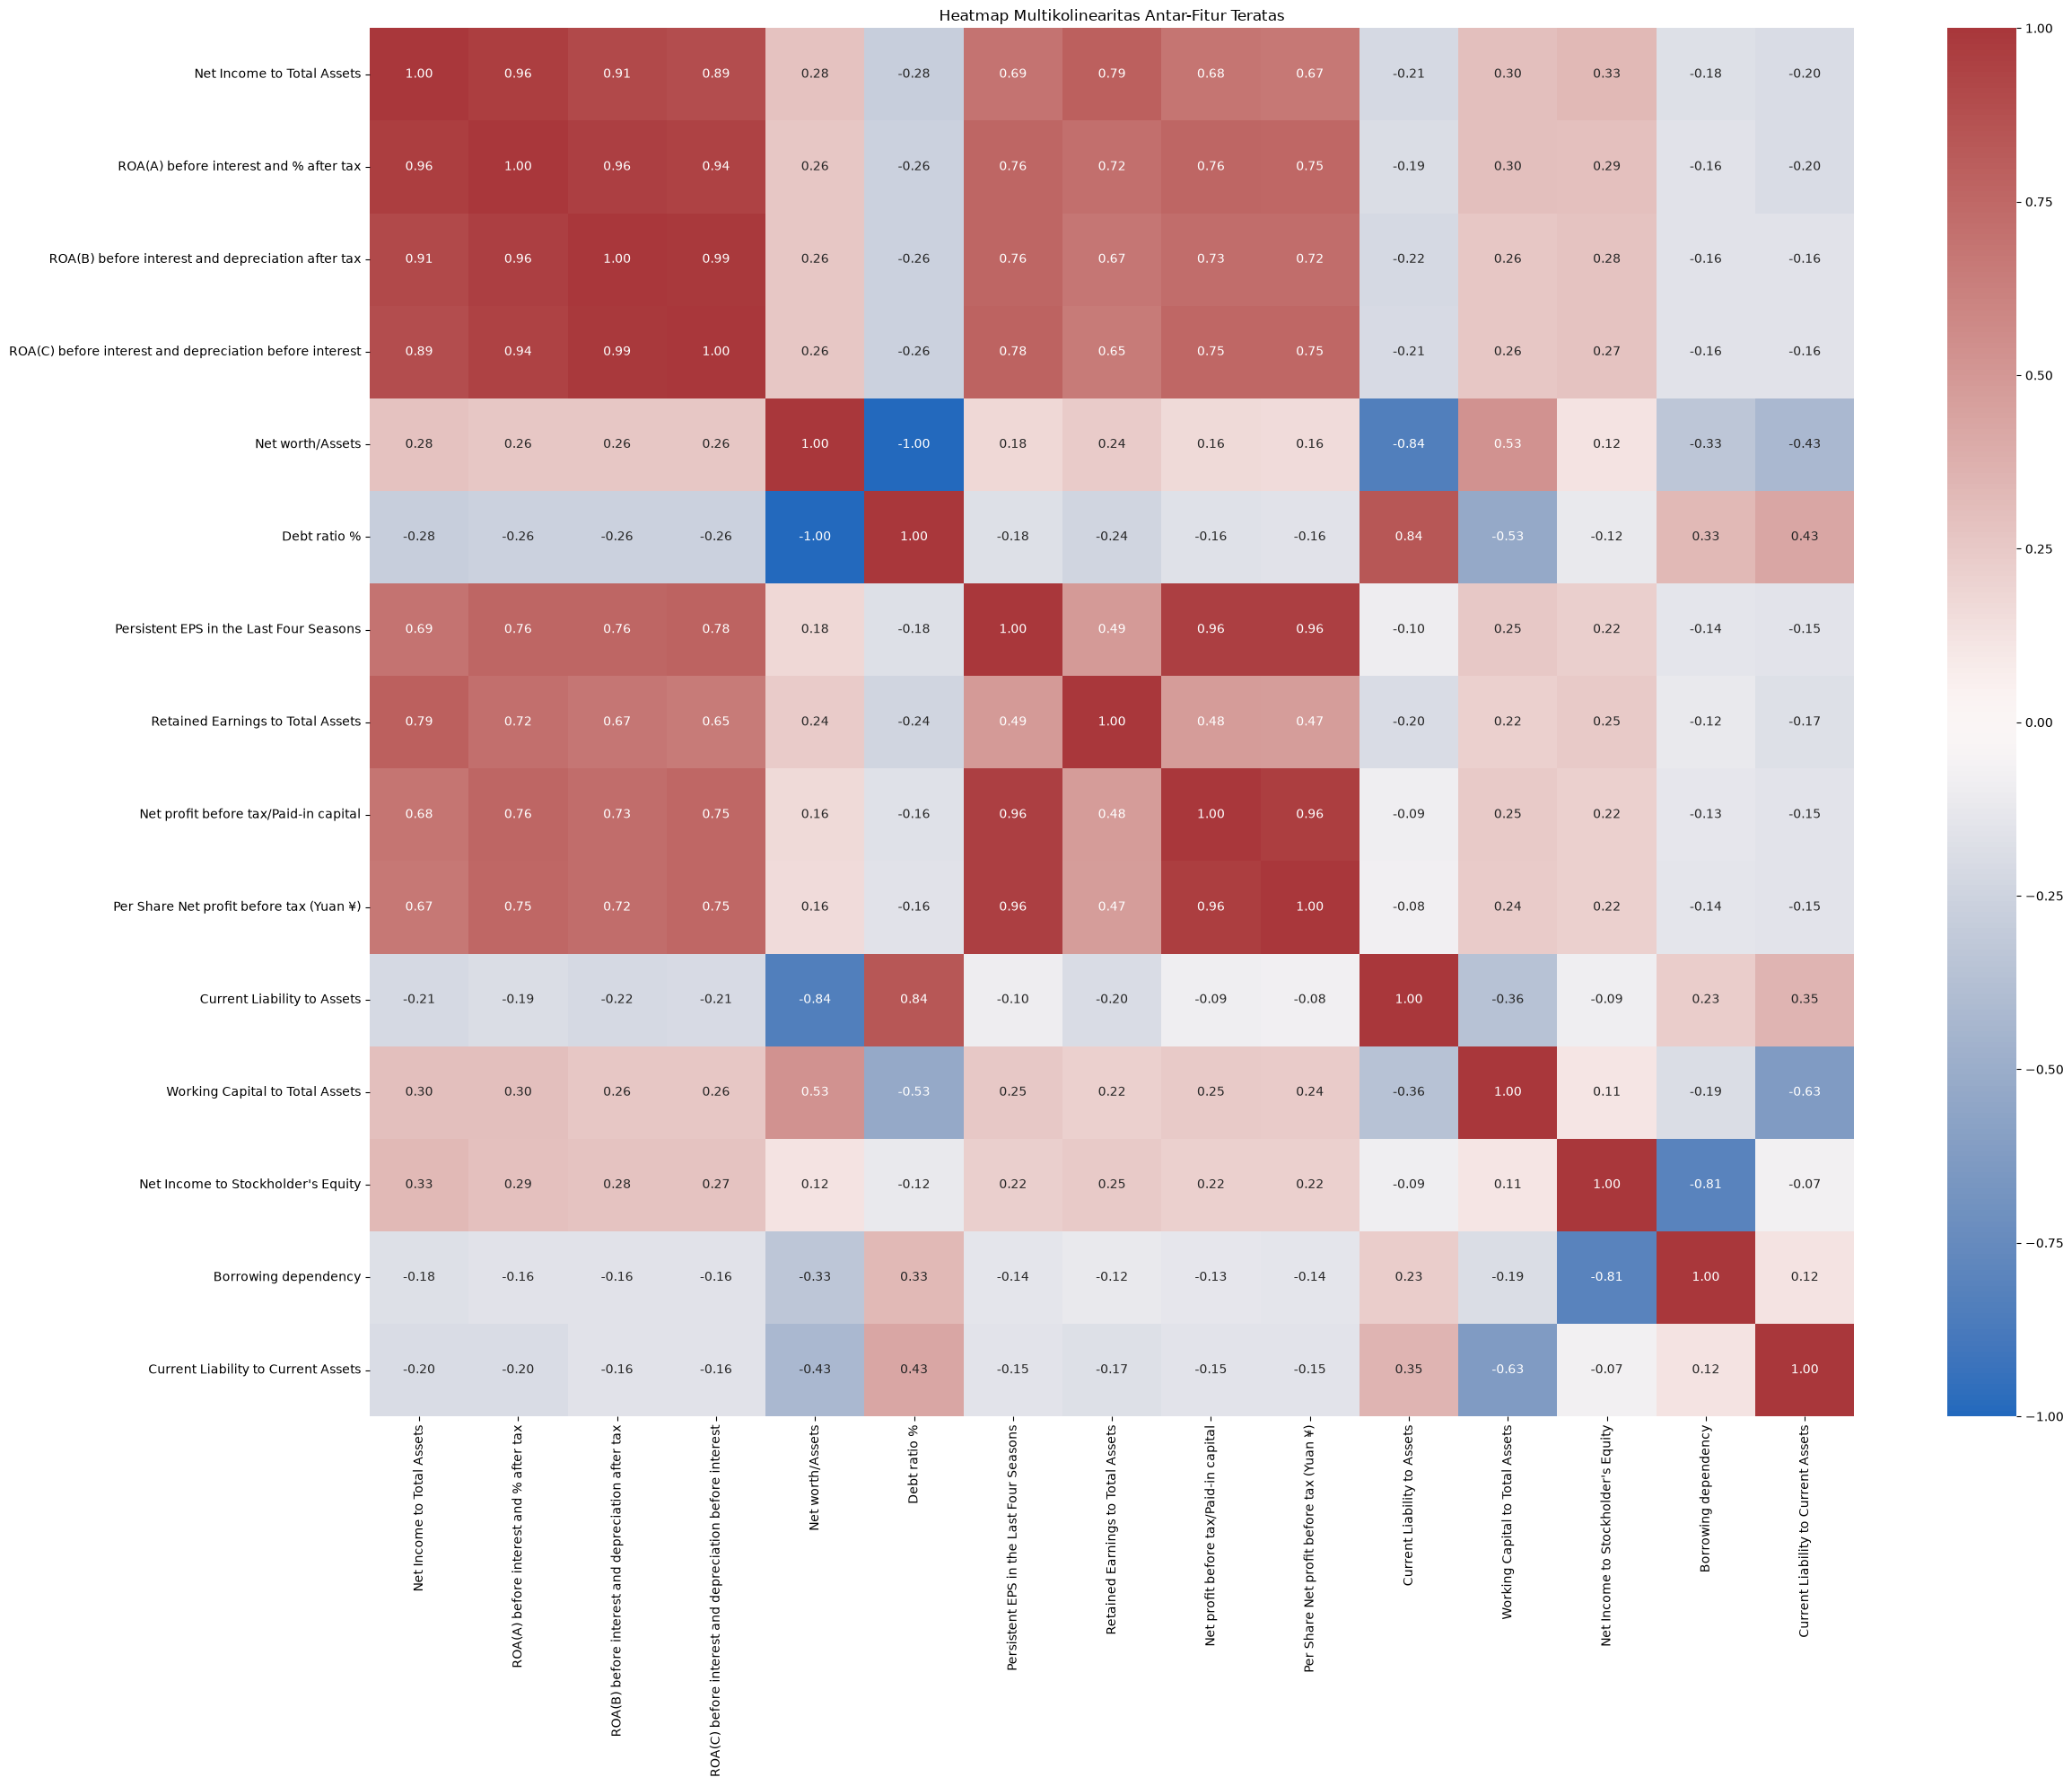

In [26]:
plt.figure(figsize=(25, 20))
sb.heatmap(bank[top].corr(), annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1)
plt.title("Heatmap Multikolinearitas Antar-Fitur Teratas")
plt.tight_layout()
plt.show()

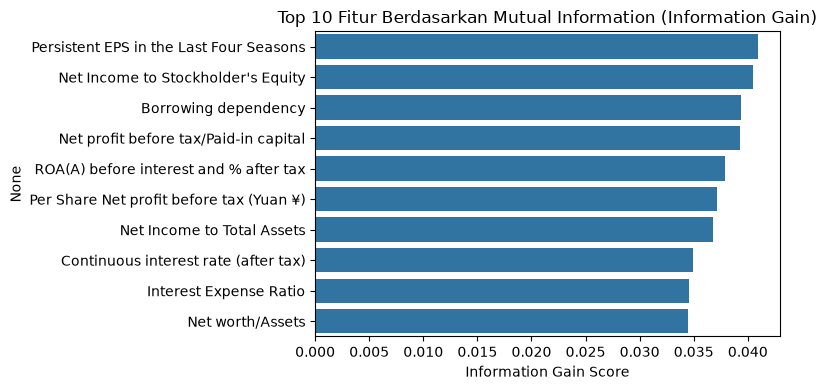

In [33]:
xe = bank.drop(columns=["Bankrupt?"])
ye = bank["Bankrupt?"]
mi = mutual_info_classif(xe, ye, random_state=67)
mi_series = pd.Series(mi, index=xe.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 4))
sb.barplot(x=mi_series.values, y=mi_series.index)
plt.title("Top 10 Fitur Berdasarkan Mutual Information (Information Gain)")
plt.xlabel("Information Gain Score")
plt.tight_layout()
plt.show()

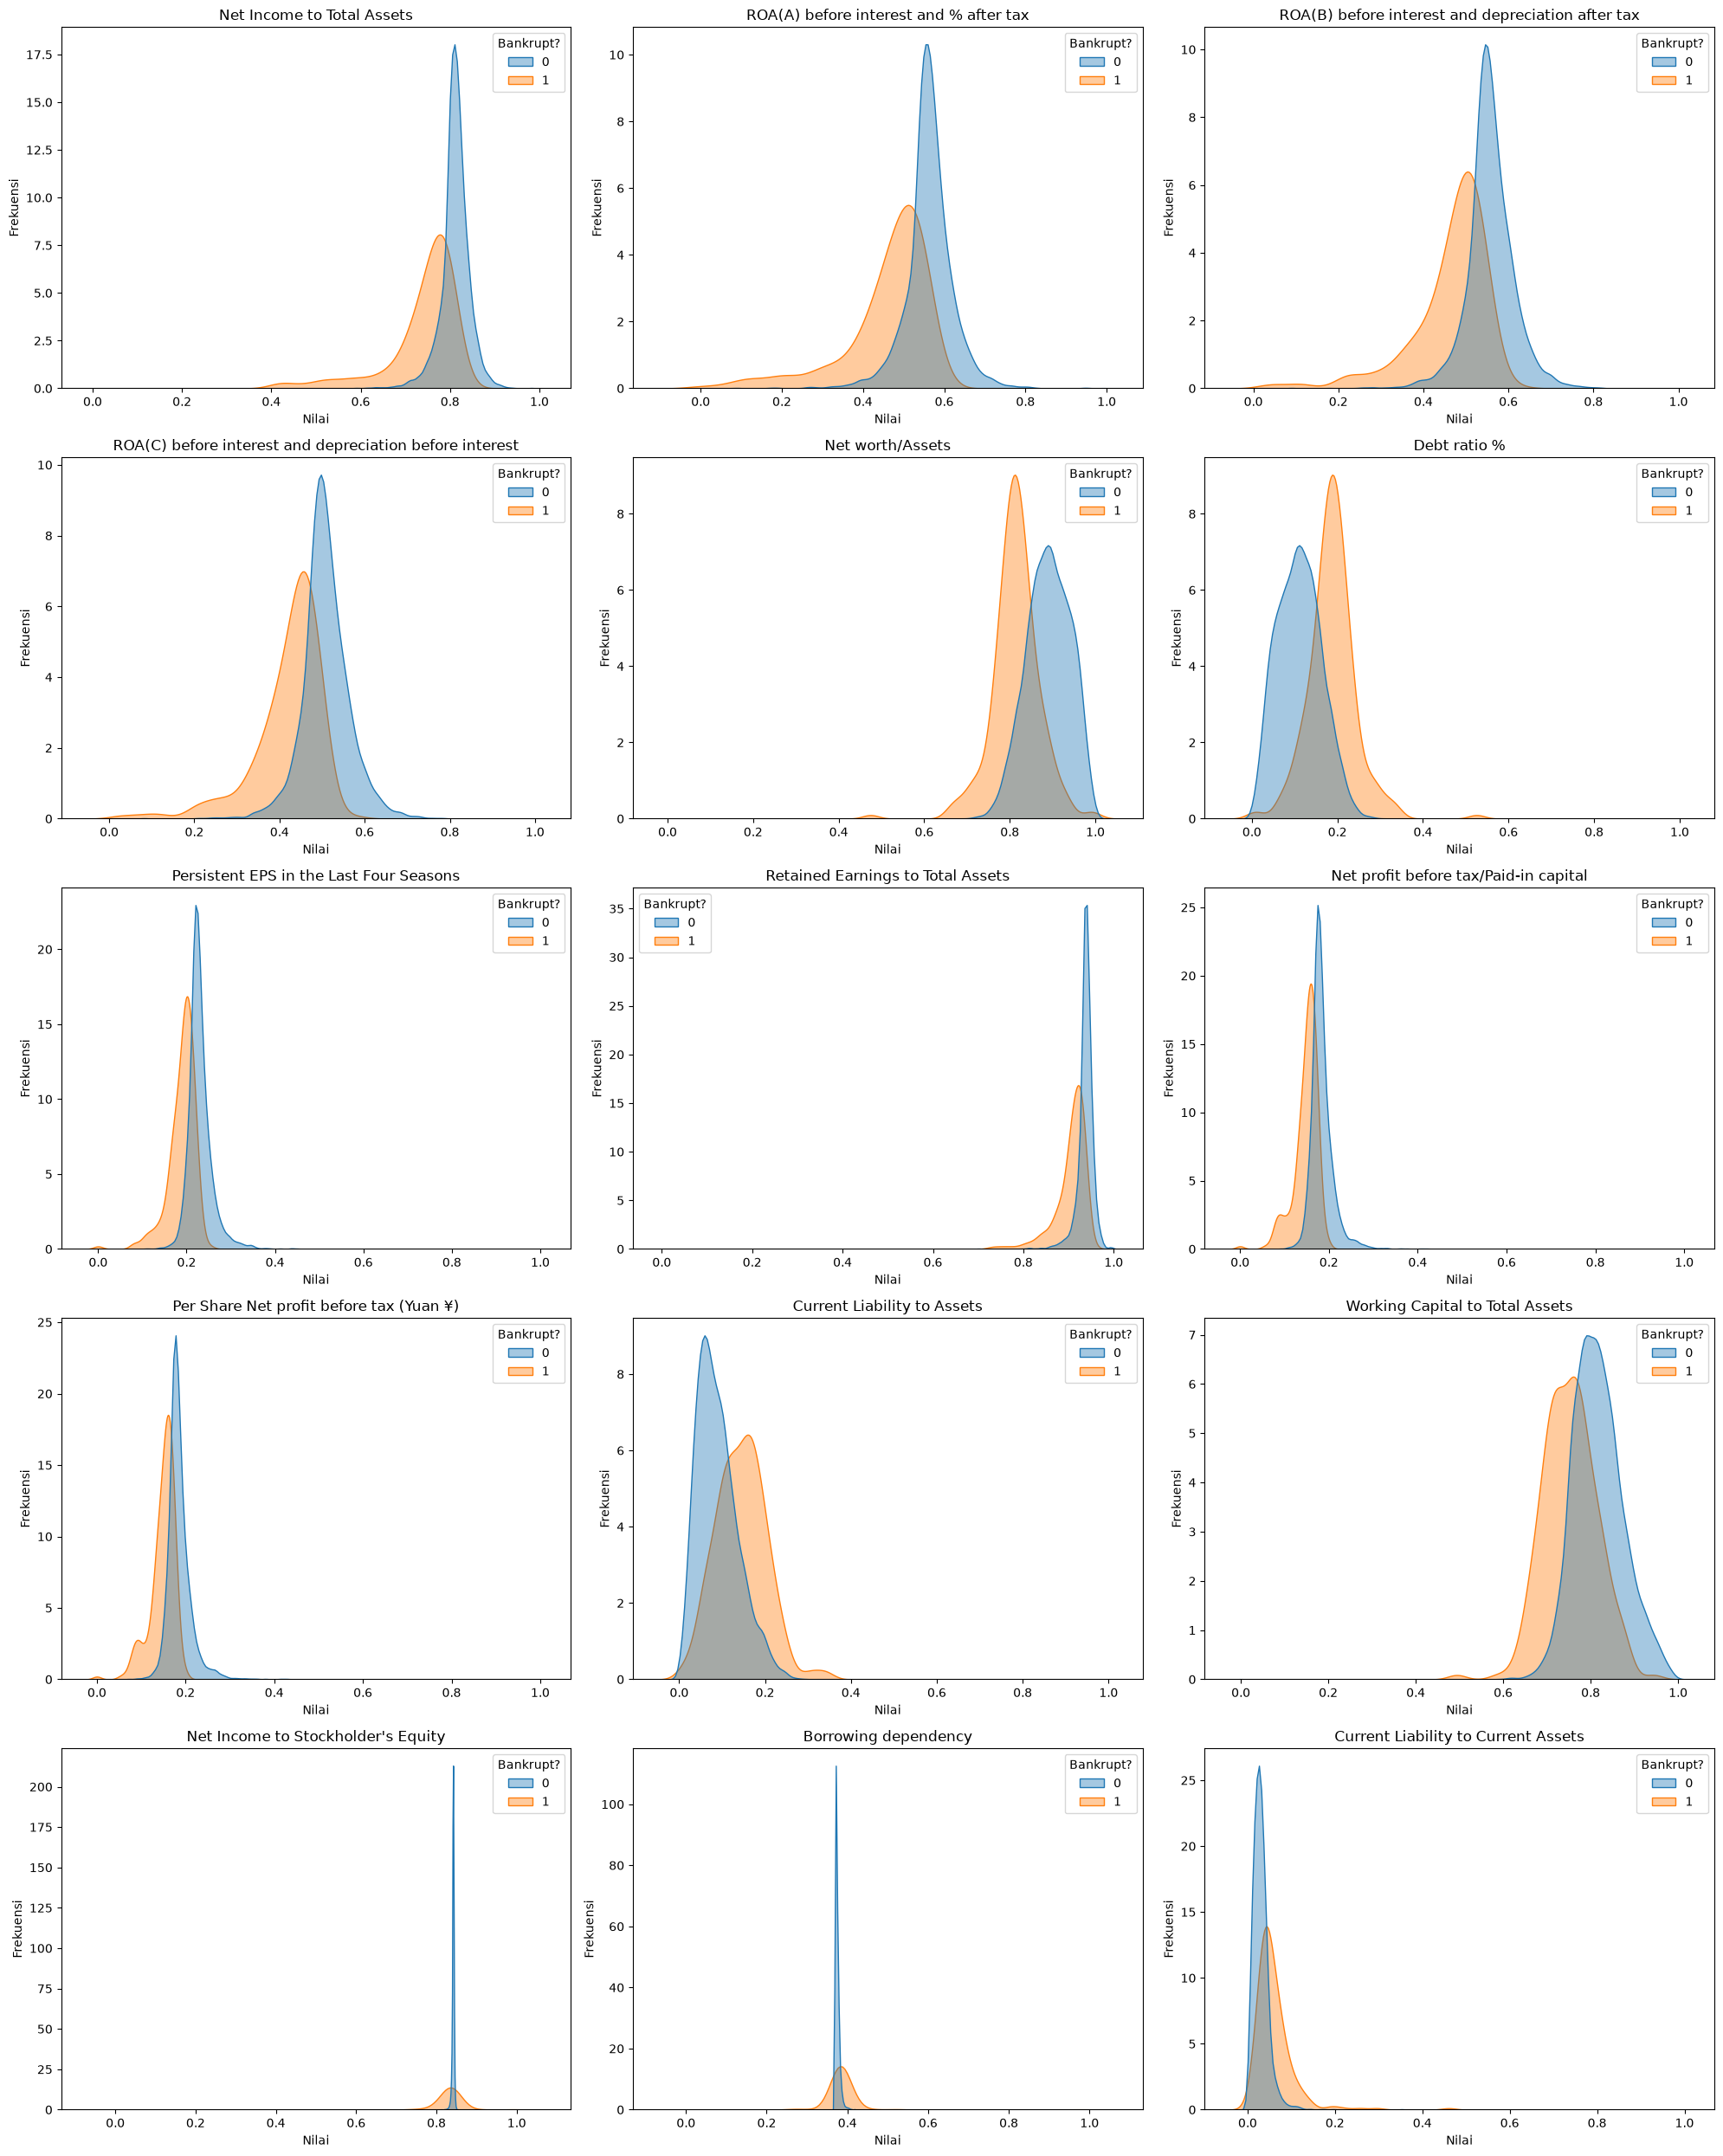

In [11]:
fig, axes = plt.subplots(5, 3, figsize=(20, 25))
axes = axes.flatten()

for ax, feature in zip(axes, top):
    sb.kdeplot(data=bank, x=feature, hue="Bankrupt?", fill=True, common_norm=False, alpha=0.4, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("Nilai")
    ax.set_ylabel("Frekuensi")

for i in range(len(top), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

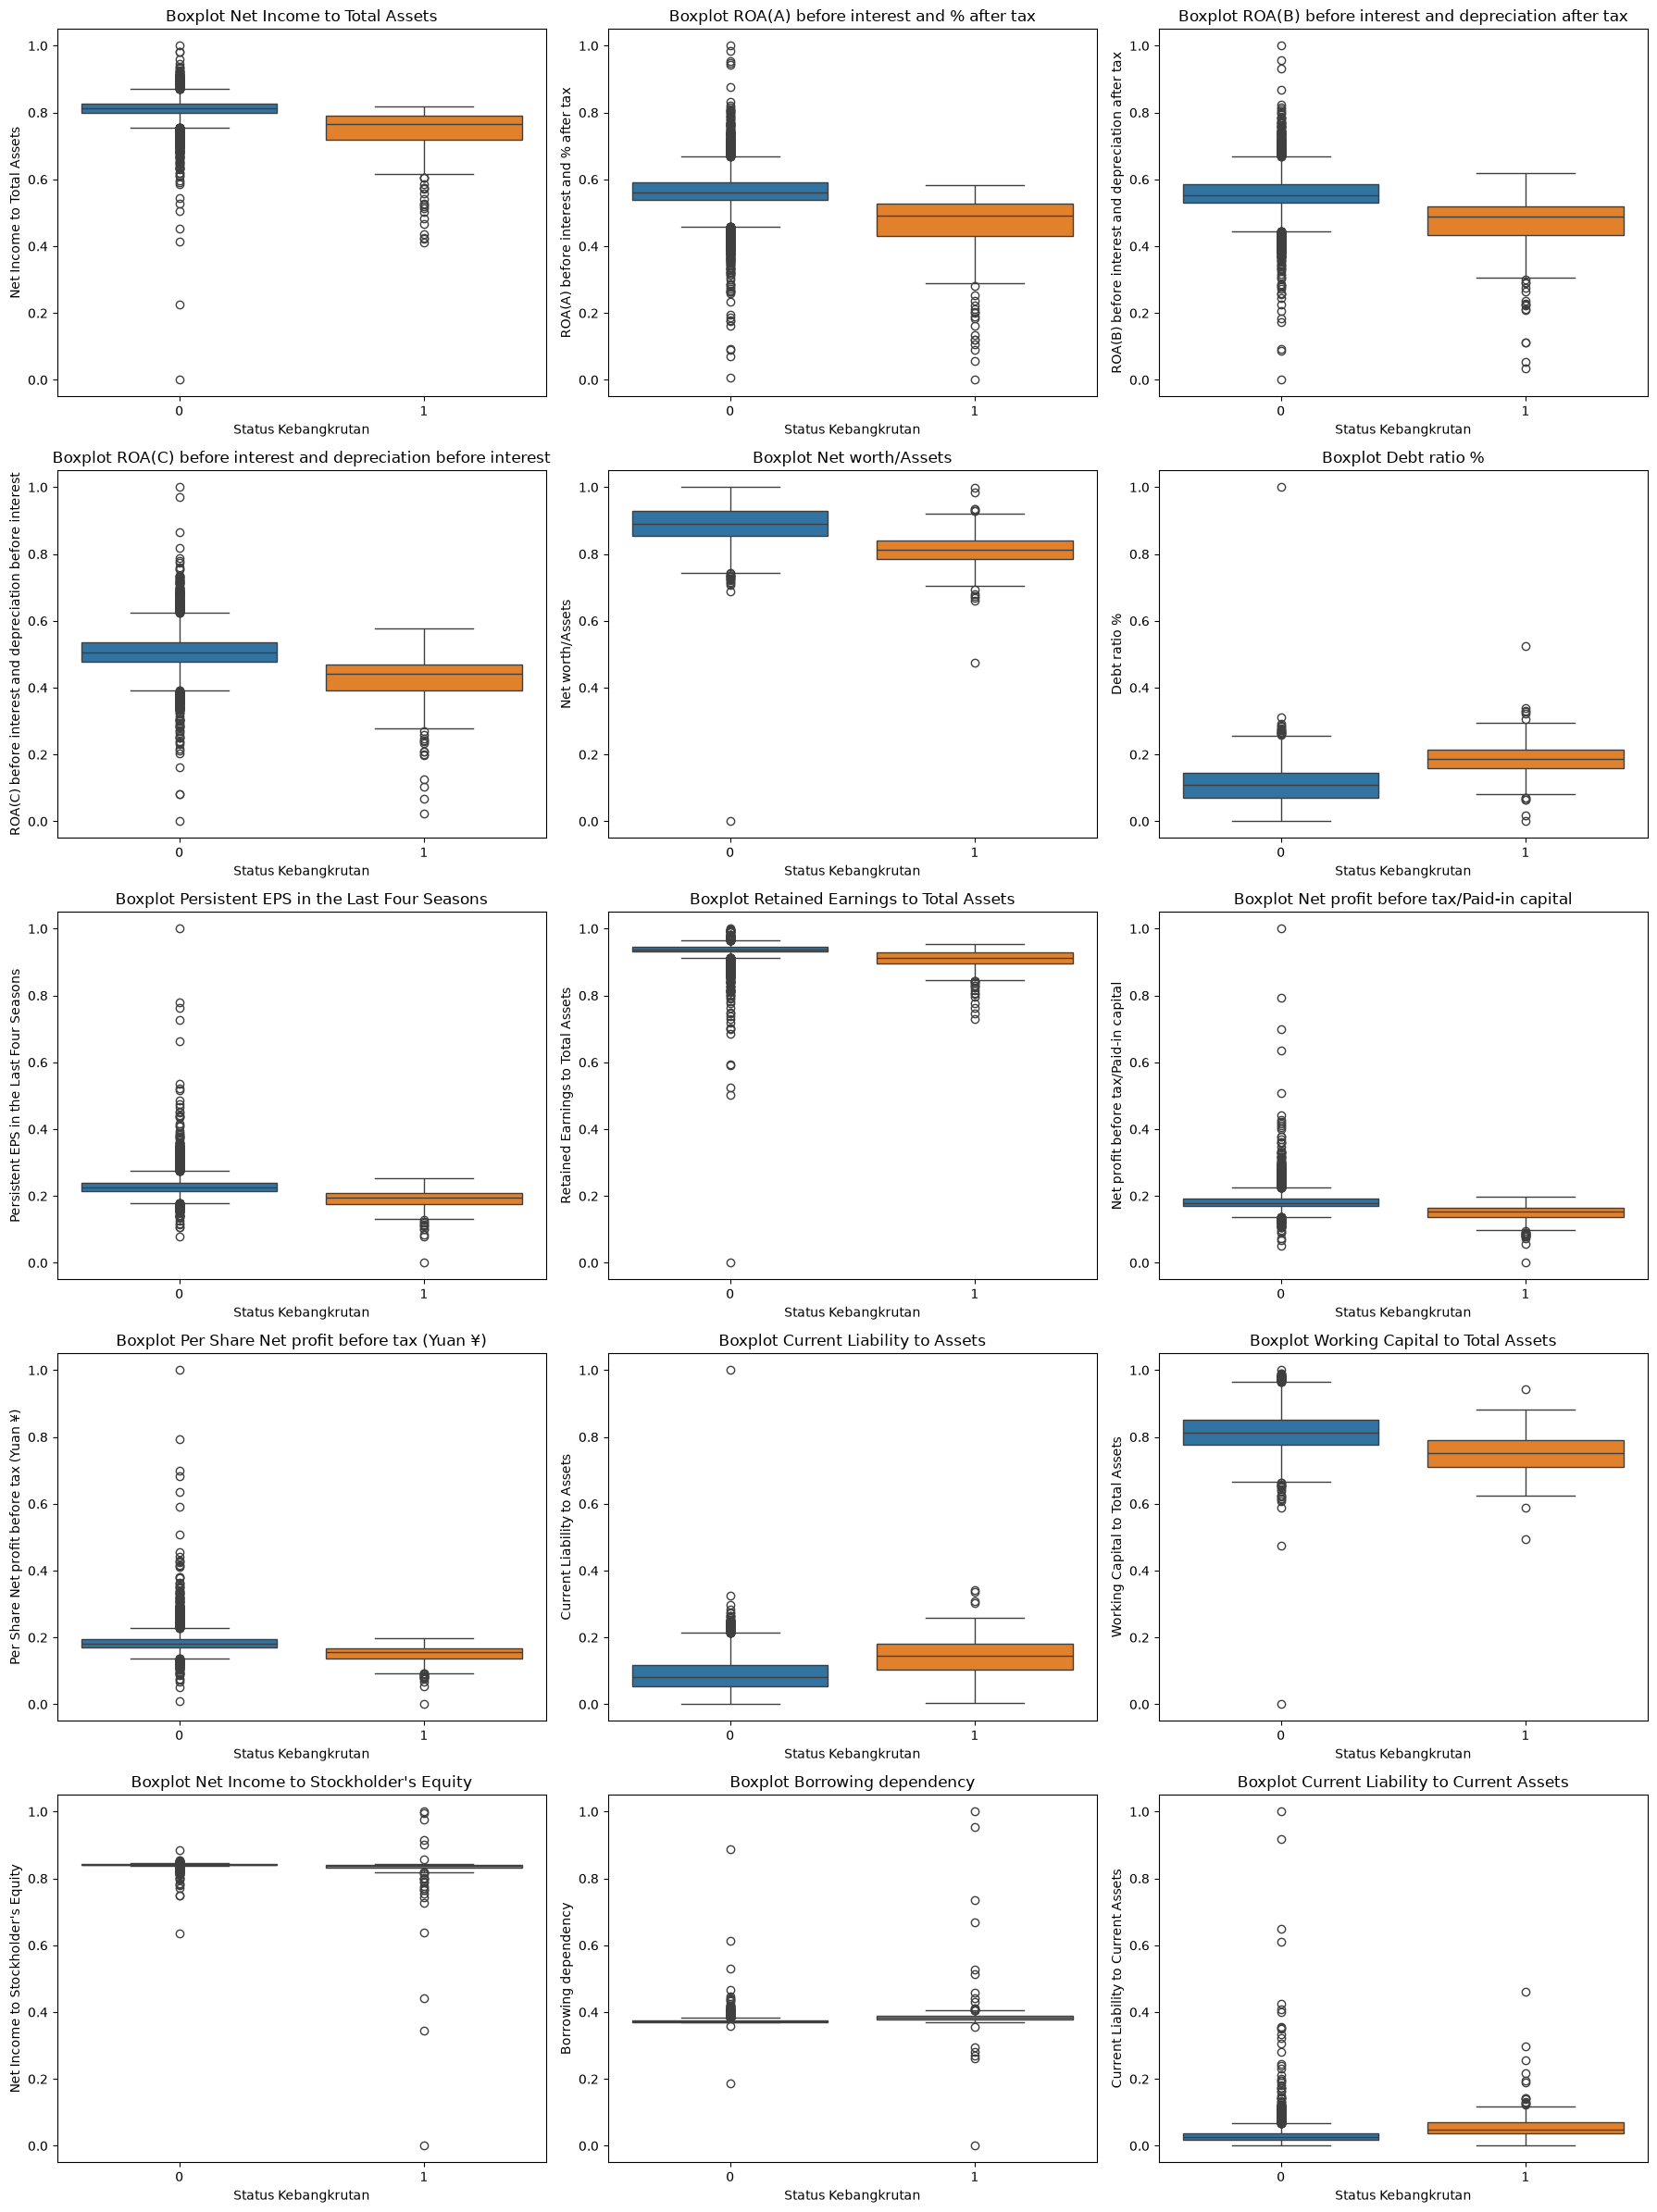

In [12]:
fig, axes = plt.subplots(5, 3, figsize=(18, 24))
axes = axes.flatten()

for ax, feature in zip(axes, top):
    sb.boxplot(data=bank, x="Bankrupt?", y=feature, hue="Bankrupt?", legend=False, ax=ax)
    ax.set_title(f"Boxplot {feature}")
    ax.set_xlabel("Status Kebangkrutan")
    ax.set_ylabel(feature)

for i in range(len(top), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

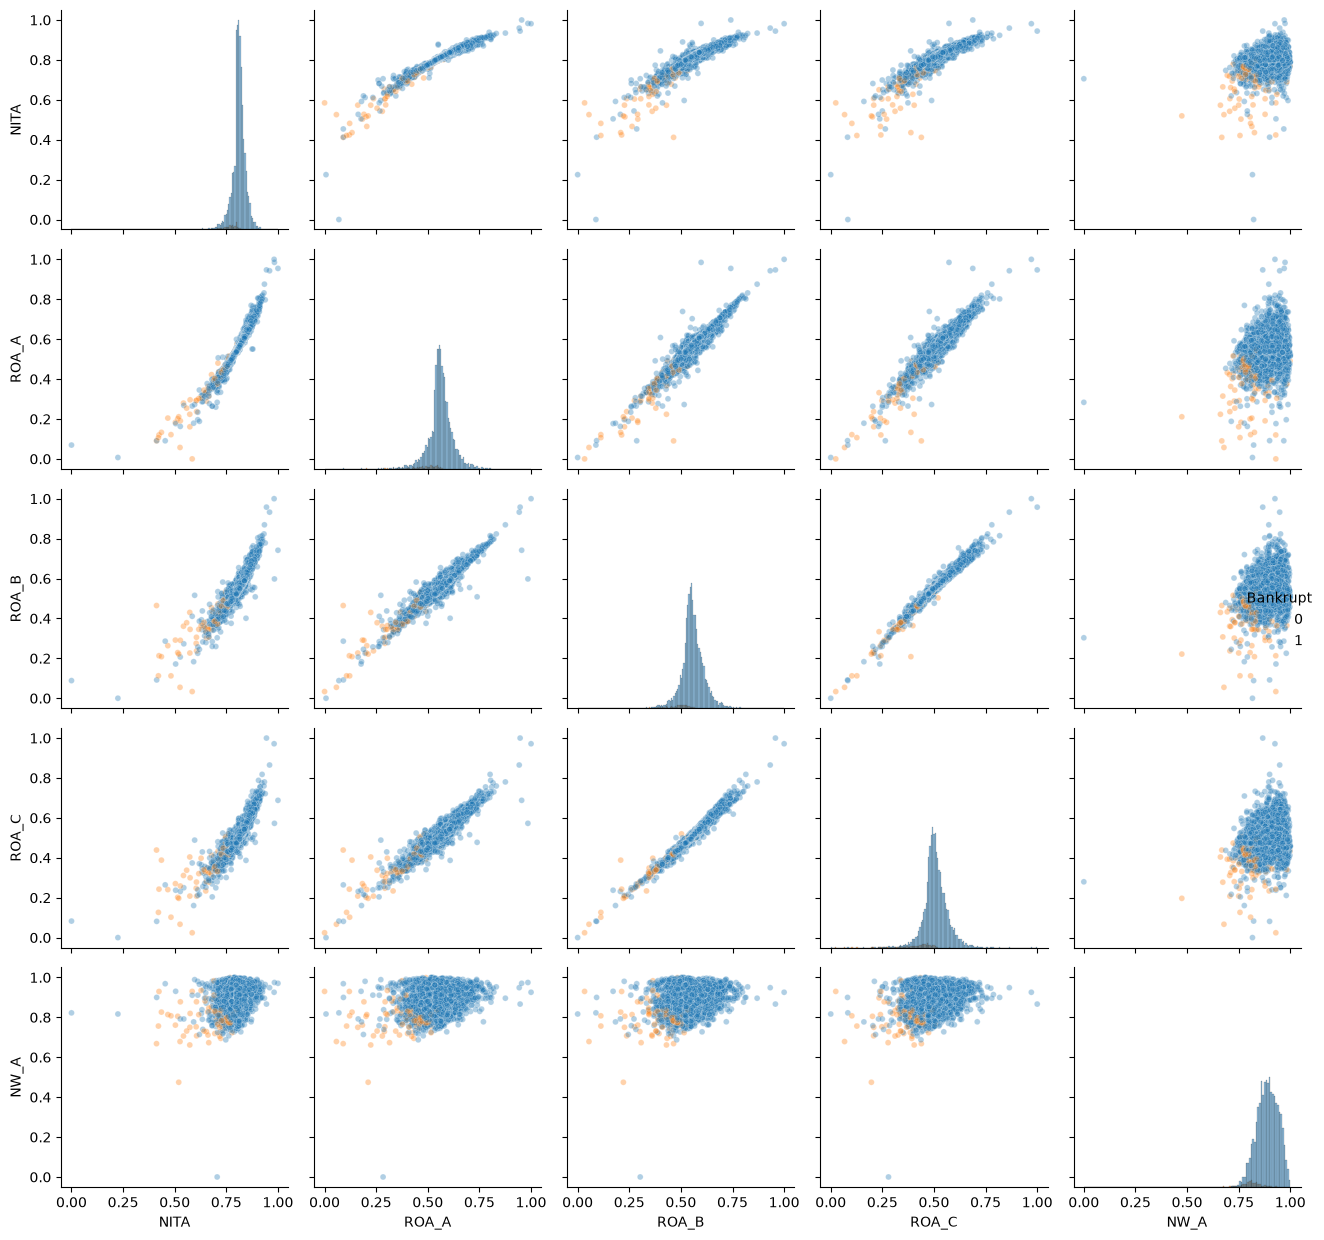

In [13]:
pairplot = top[:5] + ["Bankrupt?"]
plot = bank[pairplot].set_axis(["NITA", "ROA_A", "ROA_B", "ROA_C", "NW_A", "Bankrupt"], axis=1)
sb.pairplot(plot, hue="Bankrupt", diag_kind="hist", plot_kws={"alpha": 0.35, "s": 18})
plt.tight_layout()
plt.show()

# 2. Preprocessing

In [14]:
x = bank.drop(columns="Bankrupt?")
y = bank["Bankrupt?"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=67, stratify=y)

**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [15]:
gini = DecisionTreeClassifier(criterion="gini", random_state=67, class_weight="balanced")
gini.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",67
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are 

In [16]:
gini_pred = gini.predict(x_test)
print(accuracy_score(y_test, gini_pred))
print(recall_score(y_test, gini_pred, zero_division=0, average="weighted"))
print(precision_score(y_test, gini_pred, zero_division=0, average="weighted"))
print(f1_score(y_test, gini_pred, zero_division=0, average="weighted"))

0.9552785923753666
0.9552785923753666
0.951665134760645
0.9534053188261036


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [17]:
entropy = DecisionTreeClassifier(criterion="entropy", random_state=67, class_weight="balanced")
entropy.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",67
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features a

In [18]:
ent_pred = entropy.predict(x_test)
print(accuracy_score(y_test, ent_pred))
print(recall_score(y_test, ent_pred, zero_division=0, average="weighted"))
print(precision_score(y_test, ent_pred, zero_division=0, average="weighted"))
print(f1_score(y_test, ent_pred, zero_division=0, average="weighted"))

0.9552785923753666
0.9552785923753666
0.9576692691059006
0.956438350574361


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [19]:
depth = [1, 2, 3, 5, 10, None]
metrics = []
train_accuracies = []
test_accuracies = []
depth_labels = []

for d in depth:
    model = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=67, class_weight="balanced")
    model.fit(x_train, y_train)
    y_pred_test = model.predict(x_test)
    y_pred_train = model.predict(x_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    train_acc = accuracy_score(y_train, y_pred_train)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    depth_labels.append(str(d) if d is not None else "None")
    metrics.append({
        "Model (Max Depth)": d if d is not None else "None (Uncapped)",
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision_score(y_test, y_pred_test, zero_division=0, average="weighted"),
        "Recall": recall_score(y_test, y_pred_test, zero_division=0, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred_test, zero_division=0, average="weighted"),
    })

metrics_df = pd.DataFrame(metrics).set_index("Model (Max Depth)")
display(metrics_df.round(4))


,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
Model (Max Depth),,,,,
1,0.7199,0.7155,0.9645,0.7155,0.8072
2,0.8486,0.8570,0.9652,0.8570,0.8996
3,0.8612,0.8688,0.9685,0.8688,0.9073
5,0.8704,0.8570,0.9596,0.8570,0.8989
10,0.9690,0.9304,0.9557,0.9304,0.9415
None (Uncapped),1.0000,0.9553,0.9577,0.9553,0.9564


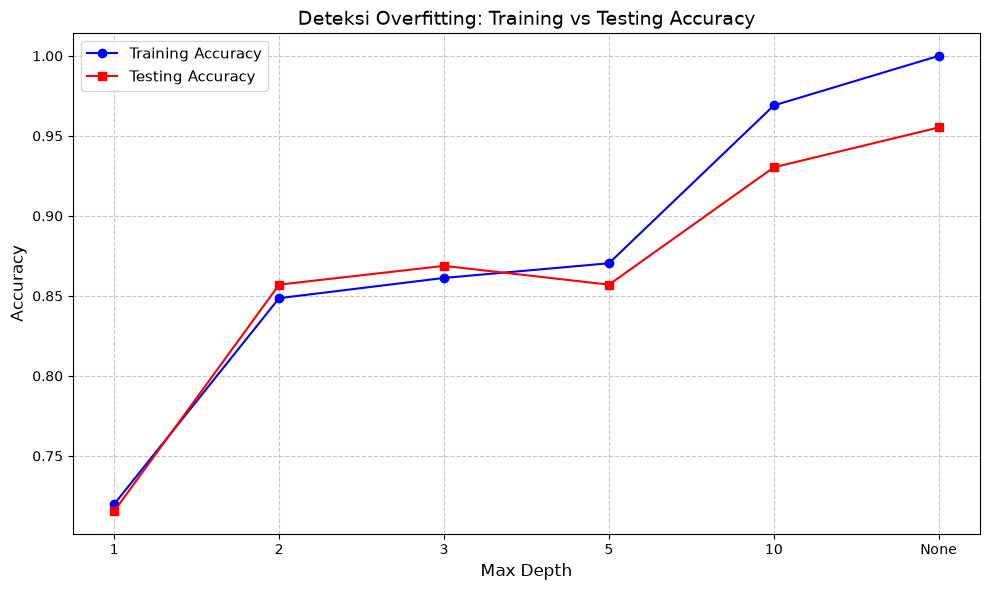

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(depth_labels, train_accuracies, marker='o', color='blue', label='Training Accuracy')
plt.plot(depth_labels, test_accuracies, marker='s', color='red', label='Testing Accuracy')
plt.title('Deteksi Overfitting: Training vs Testing Accuracy', fontsize=14)
plt.xlabel('Max Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [21]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Gini": [
        accuracy_score(y_test, gini_pred),
        precision_score(y_test, gini_pred, average="weighted", zero_division=0),
        recall_score(y_test, gini_pred, average="weighted", zero_division=0),
        f1_score(y_test, gini_pred, average="weighted", zero_division=0),
    ],
    "Entropy": [
        accuracy_score(y_test, ent_pred),
        precision_score(y_test, ent_pred, average="weighted", zero_division=0),
        recall_score(y_test, ent_pred, average="weighted", zero_division=0),
        f1_score(y_test, ent_pred, average="weighted", zero_division=0),
    ],
}).set_index("Metric")

display(comparison.round(4))

,Gini,Entropy
Metric,,
Accuracy,0.9553,0.9553
Precision,0.9517,0.9577
Recall,0.9553,0.9553
F1-Score,0.9534,0.9564


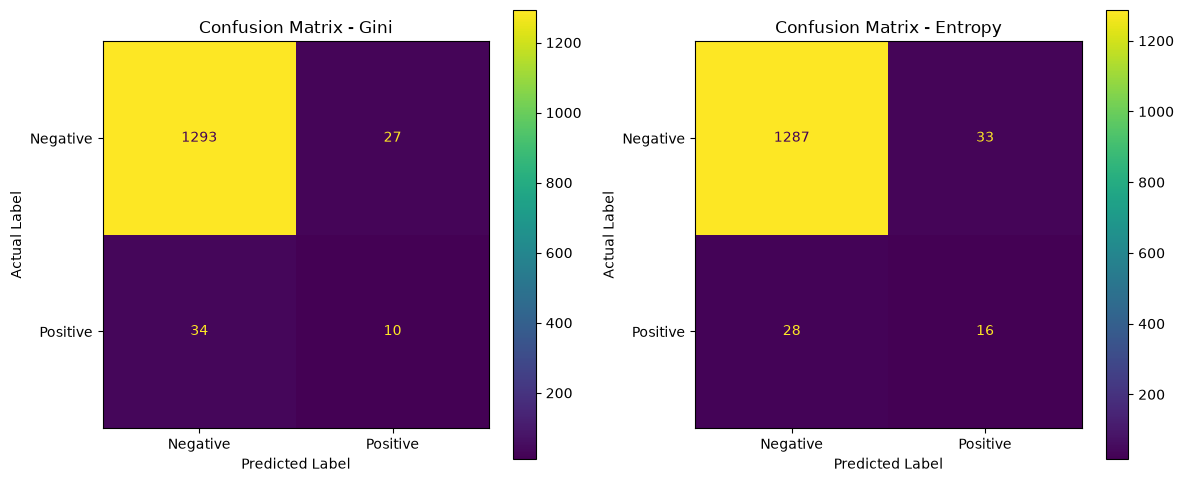

In [31]:
gini_cm = confusion_matrix(y_test, gini_pred)
entropy_cm = confusion_matrix(y_test, ent_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for ax, cm, name in zip(axes, [gini_cm, entropy_cm], ["Gini", "Entropy"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax)
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

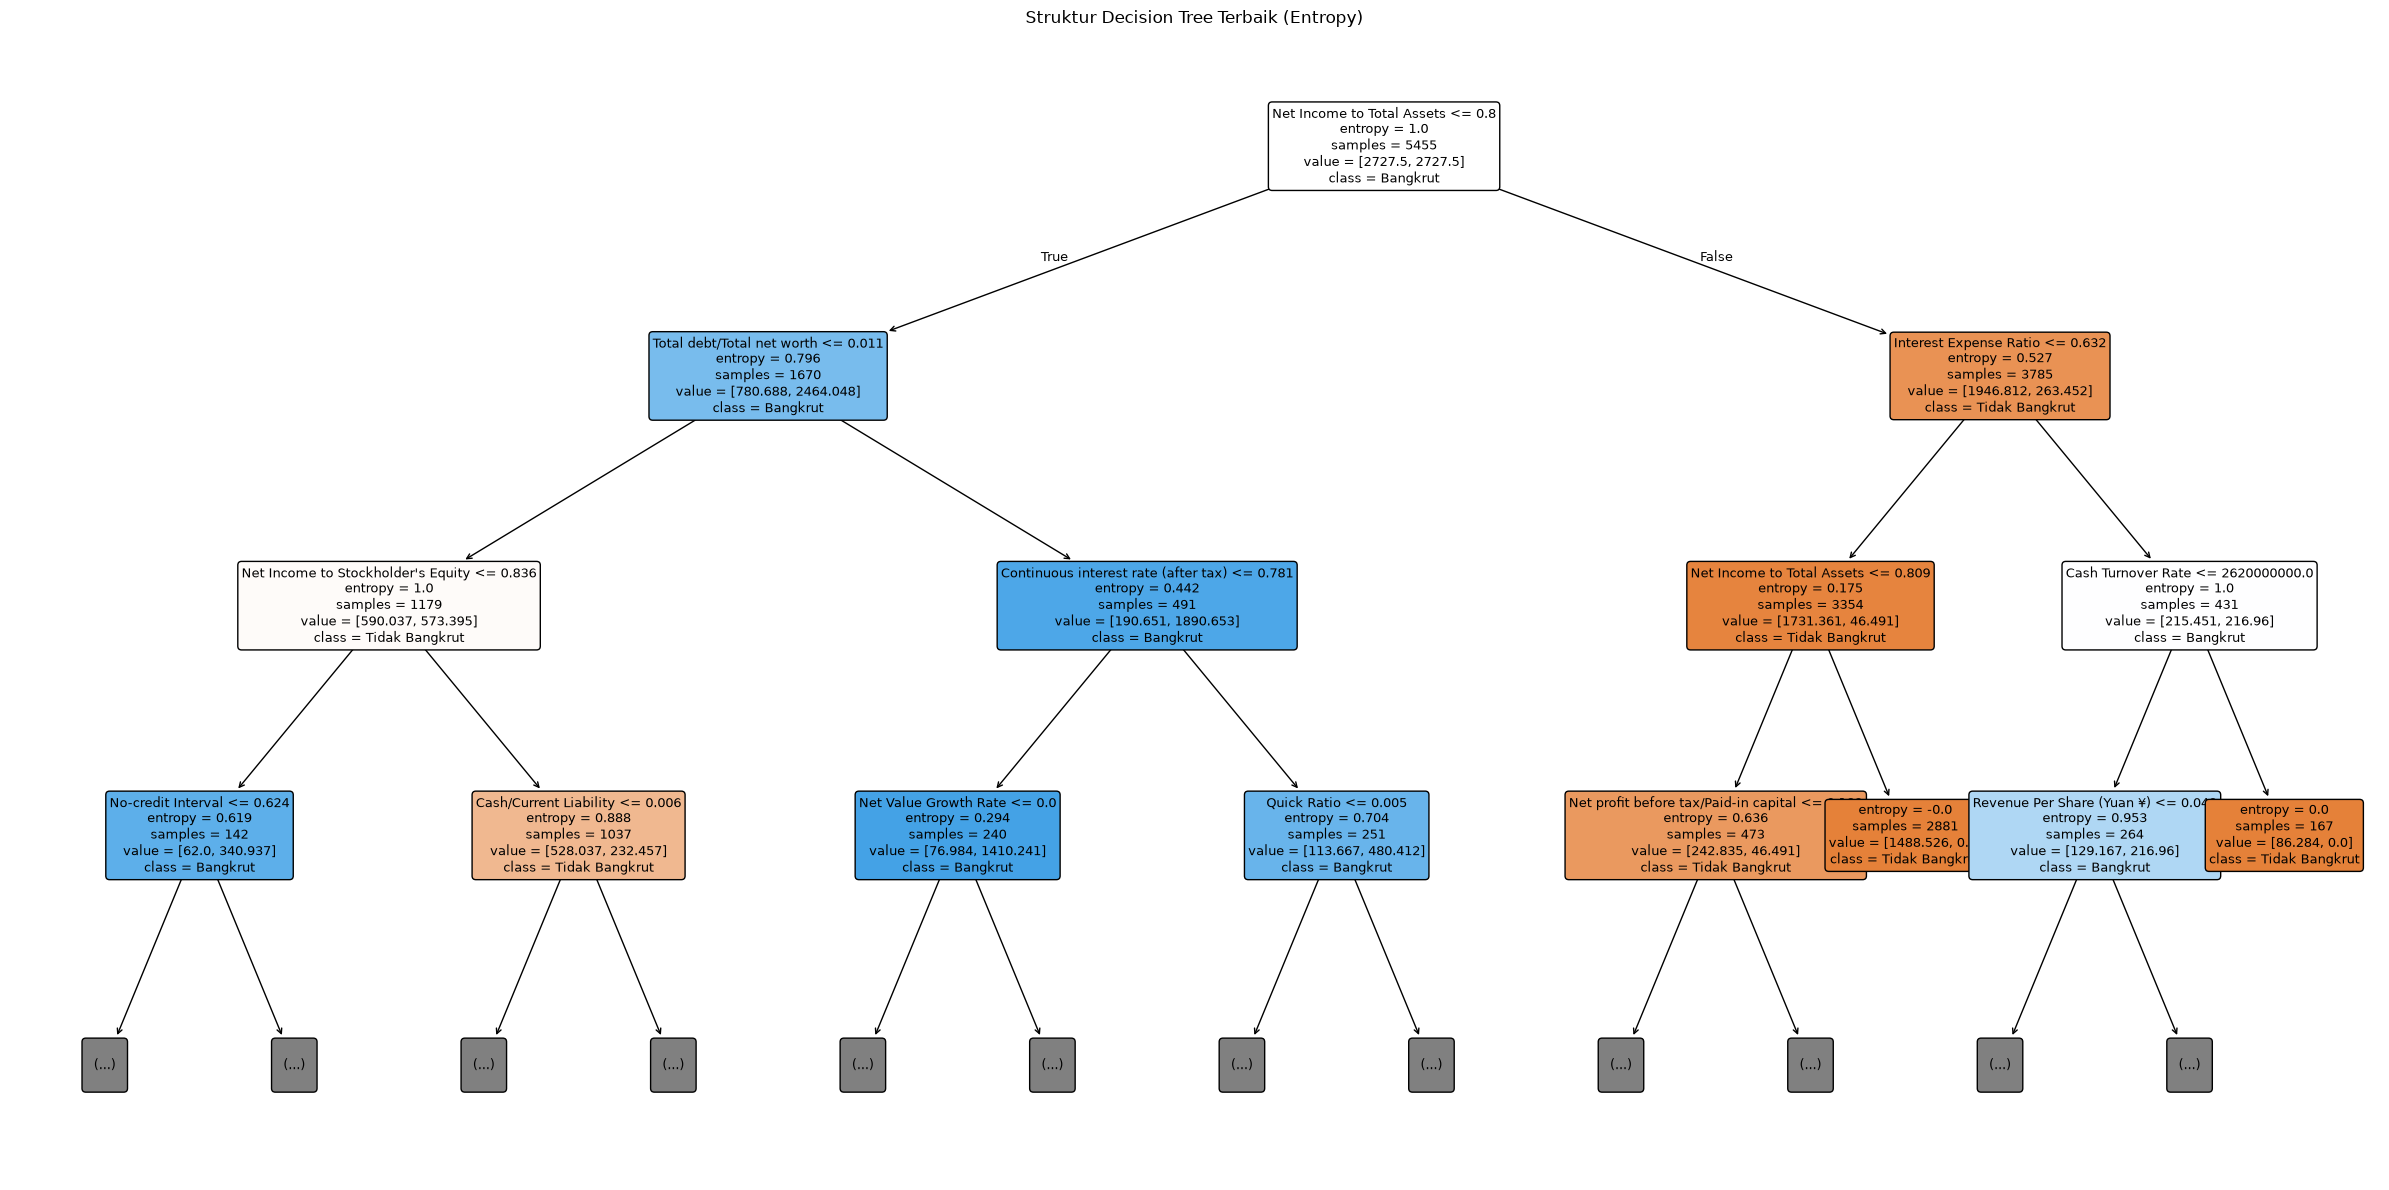

In [23]:
model_by_name = {"Gini": gini, "Entropy": entropy}
best_model_name = comparison.loc["F1-Score"].idxmax()
best_model = model_by_name[best_model_name]
plt.figure(figsize=(24, 12))
plot_tree(best_model, max_depth=3, feature_names=x.columns, class_names=["Tidak Bangkrut", "Bangkrut"], filled=True, rounded=True, fontsize=9)
plt.title(f"Struktur Decision Tree Terbaik ({best_model_name})")
plt.tight_layout()
plt.show()

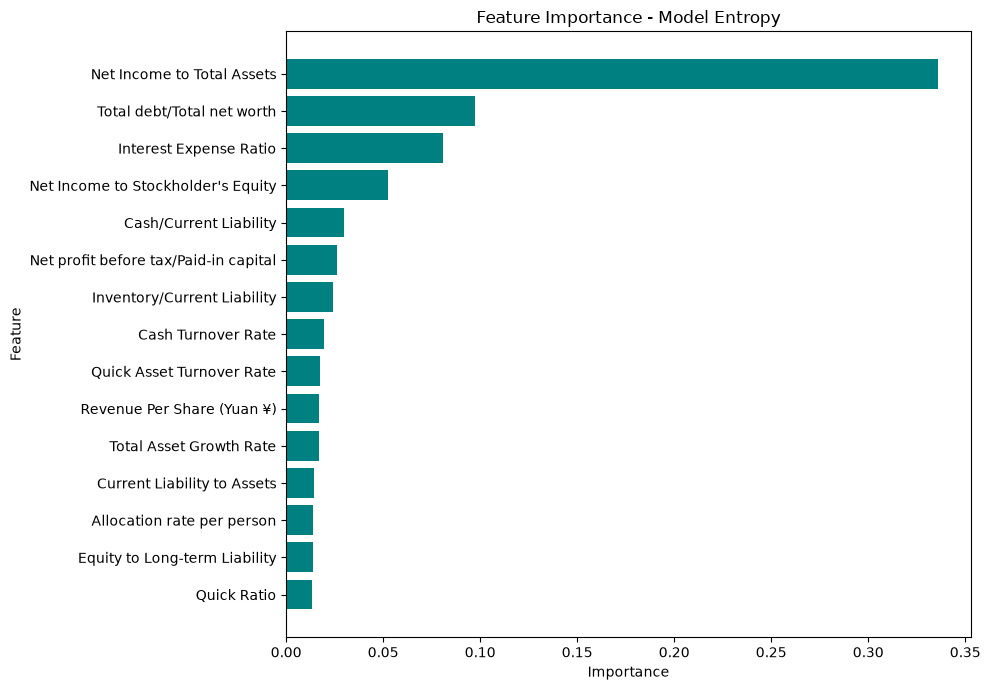

In [24]:
importance = pd.Series(best_model.feature_importances_, index=x.columns).sort_values(ascending=False).head(15).sort_values()
plt.figure(figsize=(10, 7))
plt.barh(importance.index, importance.values, color="teal")
plt.title(f"Feature Importance - Model {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 5. Analisis

### 1. Perbandingan Gini dan Entropy

Berdasarkan hasil pengujian, kedua model menghasilkan akurasi yang sama, yaitu **95,53%**. Namun, jika dilihat lebih jauh, terdapat perbedaan pada kemampuan model dalam mendeteksi perusahaan bangkrut.

Pada model **Gini**, Recall kelas 1 sebesar **22,73%**, Precision sebesar **27,02%** dan F1-score sebesar **24,69%**.

Pada model **Entropy**, Recall kelas 1 meningkat menjadi **36,36%**, Precision sebesar **32,65%** dan F1-score menjadi **34,41%**.

Jadi, walaupun akurasi kedua model sama, **Entropy lebih baik dalam mendeteksi kelas bangkrut** pada dataset ini. Perbedaan tersebut terjadi karena Gini dan Entropy menggunakan cara yang berbeda dalam menentukan split pada Decision Tree. Pada data yang tidak seimbang seperti dataset ini, perbedaan tersebut dapat menghasilkan pohon dengan kemampuan mendeteksi kelas minoritas yang berbeda.

### 2. Pengaruh `max_depth` dan overfitting

Pengujian `max_depth` dilakukan untuk melihat pengaruh kedalaman Decision Tree terhadap performa model.

Pada `max_depth = 1`, akurasi training hanya **71,99%** dan testing **71,55%**. Model masih terlalu sederhana sehingga belum mampu menangkap pola pada data. Kondisi ini menunjukkan underfitting.

Pada `max_depth = 3`, akurasi training menjadi **86,12%** dan testing **86,88%**. Pada titik ini, performa testing mencapai hasil terbaik dalam percobaan kedalaman yang diuji pada rentang tersebut.

Setelah itu, mulai terlihat tanda-tanda overfitting. Pada `max_depth = 5`, akurasi training naik menjadi **87,04%**, tetapi akurasi testing justru turun menjadi **85,70%**. 

Pada `max_depth = 10`, training accuracy sudah mencapai **96,90%**, sedangkan testing accuracy hanya **93,04%**.

Pada `max_depth = None`, model mencapai **100%** akurasi training, tetapi testing accuracy hanya **95,53%**. Ini menunjukkan bahwa pohon yang terlalu dalam mulai terlalu menyesuaikan diri dengan data training.

Dari hasil tersebut, `max_depth = 3` merupakan yang terbaik, karena tidak underfitting maupun overfitting.
### 3. Analisis Feature Importance

Pada model Decision Tree dengan Entropy, fitur dengan feature importance terbesar adalah `Net Income to Total Assets` sebesar **33,62%**. Fitur ini berkaitan dengan kemampuan perusahaan menghasilkan laba dari aset yang dimiliki.

Berikutnya adalah:

1. `Total debt/Total net worth` = 9,74%
2. `Interest Expense Ratio` = 8,08%
3. `Net Income to Stockholder's Equity` = 5,25%
4. `Cash/Current Liability` = 2,97%

Dari hasil tersebut, fitur yang cukup banyak digunakan oleh model berkaitan dengan profitabilitas, utang, beban bunga, dan likuiditas. Hal ini linear dengan teori keuangan klasik (Altman Z-Score), di mana pilar utama kebangkrutan ditentukan oleh kombinasi profitabilitas (ROA/ROE), solvabilitas (Debt/Equity), dan liquiditas (Cash/Liability).

# 6. Kesimpulan dan Saran

### Kesimpulan
1. Entropy lebih baik dalam mendeteksi perusahaan bangkrut.
   Kedua model memiliki akurasi yang sama, yaitu **95,53%**, tetapi Entropy memiliki *recall* kelas bangkrut yang lebih tinggi, yaitu **36,36%** dibandingkan **22,73%** pada Gini. Entropy juga berhasil mendeteksi 16 perusahaan bangkrut, sedangkan Gini hanya 10 perusahaan.

2. Kedalaman pohon memengaruhi performa model.
   `max_depth` yang terlalu kecil menyebabkan underfitting, sedangkan pohon yang terlalu dalam menyebabkan overfitting. Dari eksperimen yang dilakukan, peningkatan kedalaman tidak selalu meningkatkan akurasi pada data uji. Perbedaan yang semakin besar antara akurasi training dan testing juga menunjukkan bahwa model mulai terlalu menyesuaikan diri dengan data training.

3. Profitabilitas menjadi fitur yang paling banyak digunakan model.
   Fitur dengan feature importance terbesar adalah **`Net Income to Total Assets` (33,62%)**, diikuti `Total debt/Total net worth` (9,74%) dan `Interest Expense Ratio` (8,08%). Secara umum, model banyak menggunakan informasi yang berkaitan dengan profitabilitas, utang, dan kemampuan perusahaan memenuhi kewajibannya.

### Saran
1. Mencoba `ccp_alpha` untuk melakukan *pruning* dan mencari ukuran pohon yang lebih optimal.
2. Menguji `min_samples_split` dan `min_samples_leaf` untuk mengurangi kemungkinan model terlalu menyesuaikan diri dengan data training.
3. Menangani class imbalance, misalnya dengan `class_weight='balanced'` atau metode seperti SMOTE.
